# 앙상블 모형 기반 신용카드 일별 매출 예측

## Summary
- **앙상블 모형은 일별 매출을 비교적 정확하게 예측한다.**  
  (2020~2023 학습 데이터 기반, 2024년 1월 예측 기준)
- **RandomForest** 모델이 CV와 최종 테스트 모두에서 일관되게 가장 우수한 성능을 보였다.
- 매출 예측에 **연도**, **월**, **요일** 등이 중요한 영향을 미친다.


## 0. 프로젝트 개요

- **문제 인식**: 신용카드 월별 매출목표만 존재하고, 구체적인 일별 매출 예측이 부족한 상황
- **솔루션 목표**: 머신러닝을 사용하여 보다 정확한 신용카드 일별 매출을 예측하고자 함
- **예상 결과**: 일별 매출 예측을 통해 마케팅 캠페인 기획, 재무 계획 등에 활용 가능

미래 매출 예측은 마케팅 캠페인 기획, 재무 계획 설립 등 다양한 사업 영역에서 활용한다. 이 프로젝트는 신용카드 일별 매출 데이터를 기반으로 미래 매출을 예측하고자 한다. 

실제 업무 환경에서도 체계적인 매출 예측방법론이 존재하지 않고 담당자의 경험과 재량에 의존하는 경우도 많다. 체계적인 예측방법론 정립을 위해 **RandomForest**, **XGBoost**, **LightGBM** 3가지 머신러닝 모델을 사용하여 예측 성능을 비교하였다.

In [42]:
# %% 0. Environment Settings
import platform
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('ggplot')

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

## 1. 데이터 로딩

### 실제 환경에서의 데이터 로딩
실제 업무환경에서는 DW에서 데이터를 직접 추출하여 사용하였다. RDBMS 환경에서는 Oracle SQL을, Hadoop 환경에서는 Impala SQL을 사용하여 데이터를 추출한다. 보안과 규제로 인해 실제 데이터를 사용할 수 없으므로, 공개 데이터를 활용하여 Replication을 진행한다.

### Replication 데이터 출처
데이터는 **금융데이터거래소**에서 제공하는 **NH농협카드 일자별 소비현황_서울** 데이터셋을 사용한다. 데이터는 csv 파일 형태로 월별로 제공되며, 각 파일명은 '_YYYYMM' 형식으로 끝난다. 데이터 오너십을 가지고 있지 않아 리포지토리에는 제외하지만 아래 공개 데이터 링크에서 직접 다운받을 수 있다.

- **데이터**: [금융데이터거래소 - NH농협카드 일자별 소비현황](https://www.findatamall.or.kr/market/dataProdList?prodCd=GENERAL&menuNo=28)
- 훈련 데이터: 2020.01 ~ 2023.12 서울 지역 일자별 소비현황
- 검증 데이터: 2024.01 서울 지역 일자별 소비현황
- 주요 컬럼은 카드 사용 금액과 건수, 승인 일자 등의 정보를 포함한다.


In [43]:
# %% 1. LOAD THE DATA
# Data Source: KDX Data - [NH농협카드] 일자별 소비현황_서울
bas_ym = pd.date_range(start='20200101', end='20240131', freq='MS').strftime('%Y%m').tolist()

df = pd.DataFrame()

for i, var in enumerate(bas_ym):
    data_path = f'data/[NH농협카드] 일자별 소비현황_서울_{var}.csv'
    
    # Read the data with available encodings
    encodings = ['utf-8-sig', 'euc-kr', 'cp949']
    for encoding in encodings:
        try:
            tmp_df = pd.read_csv(data_path, encoding=encoding)
            break
        except UnicodeDecodeError:
            continue
    else:
        raise ValueError(f"Failed to read {data_path} with available encodings.")
    
    df = pd.concat([df, tmp_df], axis=0)
    
print(df.shape)
print(df.head())

(1643, 8)
   시도      승인일자  이용건수_전체  이용금액_전체  이용건수_개인  이용금액_개인  이용건수_법인  이용금액_법인
0  서울  20200101   1827.0  48116.0   1770.0  45654.0     57.0   2462.0
1  서울  20200102   2071.0  78042.0   1932.0  66654.0    139.0  11388.0
2  서울  20200103   2140.0  77224.0   1995.0  64302.0    144.0  12922.0
3  서울  20200104   1969.0  55070.0   1891.0  51702.0     78.0   3369.0
4  서울  20200105   1711.0  46359.0   1649.0  43796.0     62.0   2563.0


## 2. 데이터 전처리

### 2.1. 데이터 타입 변환
승인일자를 `datetime64` 타입으로 변환하고 금액 변수들의 단위를 분석에 용이하게 변경한다. (백만원 -> 억원)

### 2.2. 파생 변수 생성
연도(`year`), 월(`month`), 일(`day`), 요일(`dayofweek`), 주말 여부(`weekend`) 등의 파생 변수를 생성하여 모델에 활용할 수 있도록 한다. 금액의 평균을 나타내는 변수들도 분석 참고용으로 생성한다 (`avg_sales`, `avg_sales_psn`, `avg_sales_cor`).

### 2.3. 범주형 변수 변환
요일(`dayname`) 변수를 순서형 변수로 변환하여 모델에 활용한다. 요일은 명목형 범주에 해당하지만, 시각화 등을 위해서 순서형으로 변환하는 것이 편리하다.

### 2.4. 데이터 분할
2020~2023 데이터를 훈련 데이터로 사용하여 2024년 1월 매출 예측을 수행할 것이다. 과거 4년 데이터를 학습하여 1개월 뒤 매출을 예측함으로써 모델의 일반화 성능을 확인한다.


In [44]:
# %% 2. DATA PREPROCESSING
# Type Conversion (int64 -> datetime64)
df['date'] = pd.to_datetime(df['승인일자'], format='%Y%m%d')

# Decimal Point Handling
df['이용금액_전체_억원'] = df['이용금액_전체'] / 100
df['이용금액_개인_억원'] = df['이용금액_개인'] / 100
df['이용금액_법인_억원'] = df['이용금액_법인'] / 100

# Derived Variables
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

# Nominal to Ordinal Variable
df['dayname'] = pd.Categorical(df['date'].dt.day_name(), 
                               categories=['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday'],
                               ordered=True)

# Add weekend variable
df['weekend'] = df['dayname'].isin(['Saturday', 'Sunday'])

# Nullity Check
print(df.isna().sum())

# Train-Test Split
df_train = df[df['year'] != 2024]
df_test = df[df['year'] == 2024]

print(df_train.shape, df_test.shape)

# Reset Index
df.reset_index(drop=True, inplace=True)

시도            0
승인일자          0
이용건수_전체       0
이용금액_전체       0
이용건수_개인       0
이용금액_개인       0
이용건수_법인       0
이용금액_법인       0
date          0
이용금액_전체_억원    0
이용금액_개인_억원    0
이용금액_법인_억원    0
year          0
month         0
day           0
dayofweek     0
dayname       0
weekend       0
dtype: int64
(1461, 18) (182, 18)


## 3. 데이터 탐색적 분석 (EDA)

### 3.1. 결측치 확인
- 데이터에서 결측치를 시각적으로 확인하고 적절히 처리한다.
- `sns.heatmap`을 사용하면 결측치를 시각화할 수 있지만 대규모 데이터의 경우 시각적으로 확인하기 힘드므로 `.sum` 등으로도 확인한다.

### 3.2. 변수 간 상관관계 확인

- 상관 행렬을 통해 변수들 간의 상관관계를 확인하고, 다중공선성 문제를 방지하기 위해 일부 변수를 제거하거나 변형할 수 있다.
- 본 분석에서는 주요 독립변수인 연도(`year`), 월(`month`), 일(`day`), 요일(`dayofweek`) 간 상관성이 낮아 변수 제거는 시행하지 않았다. 

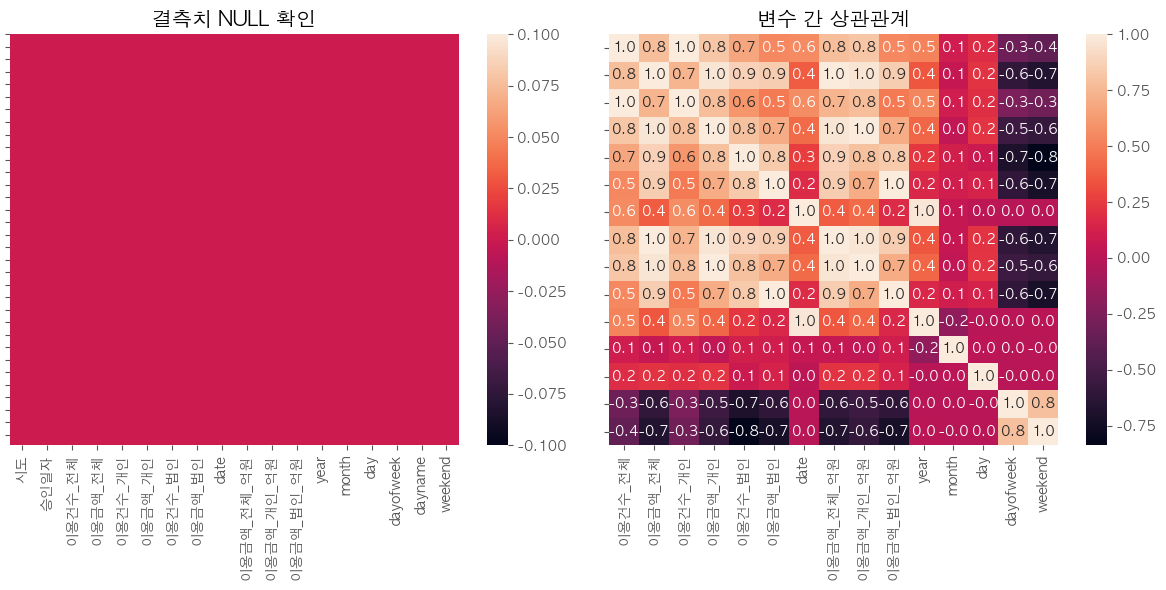

In [45]:
# %% 3. EDA
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

# 3-1. Null Handling
sns.heatmap(df.isna(), ax=axes[0])
axes[0].set_title('결측치 NULL 확인')
axes[0].set_yticklabels([])

# 3-2. Correlation Matrix (Multicolinearity Check)
corr_mat = df.drop(['시도', '승인일자', 'dayname'], axis=1).corr()

sns.heatmap(corr_mat, annot=True, fmt='.1f', ax=axes[1])
axes[1].set_yticklabels([])

axes[1].set_title('변수 간 상관관계')
plt.tight_layout()
plt.show()

### 3.3. 이상치 탐지/제거

주요 변수들에 대해 선형 그래프와 박스플롯을 사용하여 이상치를 탐지한다.

- 일반적으로는 IQR, 2표준편차 방식을 사용해서 이상치를 탐지하고 제외한다.
- **IQR을 벗어난다고 무작정 제외하지 않는다.** 예를 들어 법인 매출에는 유독 튀는 몇몇 날짜가 존재한다. 데이터 오류(이상치)일 수도 있지만 실제 주요 실적일 수 있다. 
- 법인 거래는 거래빈도는 작고 거래금액은 크다. 기계적으로 이상치로 판단해 해당 값을 제외할 경우 실적을 과소추정할 수 있다.
- raw data에 접근 가능한 상황이라면 가장 먼저 데이터를 의심하고 raw date를 확인한다. 만약 문제가 없거나 접근이 불가능한 상태라면 각 업무 담당자에게 확인하는 것이 좋다.

이러한 문제로 본 분석에서는 이상치 제거를 수행하지 않고 이후 분석을 진행한다.

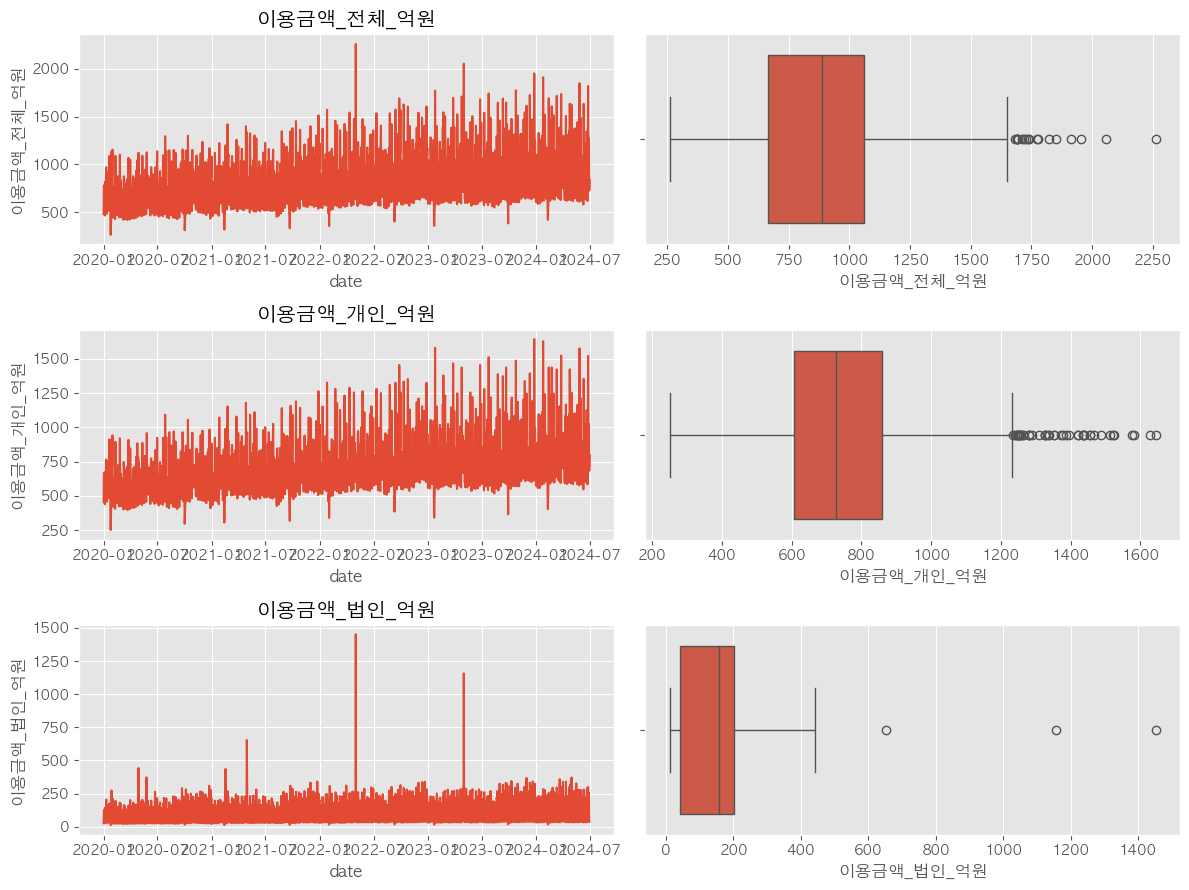

In [46]:
# 3-3. Outlier Detection
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,9))

variables = ['이용금액_전체_억원', '이용금액_개인_억원', '이용금액_법인_억원']
 
for i, vars in enumerate(variables):
    sns.lineplot(data=df, x='date', y=vars,
                ax=axes[i%3][0])
    sns.boxplot(data=df, x=vars,
                ax=axes[i%3][1])
    axes[i%3][0].set_title(vars)
    axes[i%3][0].tick_params(axis='x', rotation=30)


plt.tight_layout()
fig.suptitle('')
plt.show()

### 3.4. 매출 분석

- 매출 데이터는 요일별로 시각화하여 소비 패턴을 분석한다. 이를 통해 매출이 특정 요일에 따라 차이를 보인다는 인사이트를 도출한다.

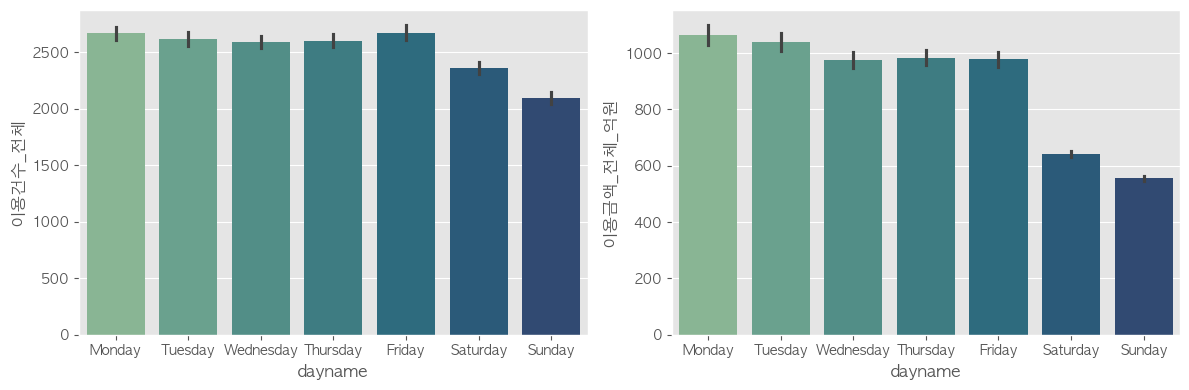

In [51]:
# 3-4. Sales by Day & Month
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))

# Row 1: 요일별
sns.barplot(data=df, x='dayname', y='이용건수_전체',
            hue='dayname', palette='crest', legend=False, ax=axes[0][0])
sns.barplot(data=df, x='dayname', y='이용금액_전체_억원',
            hue='dayname', palette='crest', legend=False, ax=axes[0][1])
axes[0][0].set_title('요일별 이용건수')
axes[0][1].set_title('요일별 이용금액 (억원)')

# Row 2: 월별
sns.lineplot(data=df, x='month', y='이용건수_전체', ax=axes[1][0])
sns.lineplot(data=df, x='month', y='이용금액_전체_억원', ax=axes[1][1])
axes[1][0].set_title('월별 이용건수')
axes[1][1].set_title('월별 이용금액 (억원)')
axes[1][0].set_xticks(range(1,13))
axes[1][1].set_xticks(range(1,13))

fig.suptitle('신용카드 이용 현황 (요일별 / 월별)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 모델링

### 4.1. 회귀 모델 설정

- 모델링을 위해 **RandomForest**, **XGBoost**, **LightGBM**을 사용하여 예측을 수행한다.
- 각 모델은 카드 사용 금액(`이용금액_개인_억원`)을 종속 변수로 설정하고, 연도, 월, 요일 등의 변수를 독립 변수로 설정하여 학습한다.
- **Time Window Expanding Cross Validation**으로 모델 성능을 평가하고, 2020~2023 전체 데이터로 최종 모델을 학습한다.


In [86]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# 4-1. Time Window Expanding Cross Validation
ind_vars = ['승인일자', 'year', 'month', 'day', 'dayofweek']
dep_var  = '이용금액_개인_억원'

df_cv_data = df[df["year"] != 2024].copy()
periods = sorted(df_cv_data['date'].dt.to_period('M').unique())

cv_results = []

for i in range(1, len(periods)):
    train_mask = df_cv_data['date'].dt.to_period('M').isin(periods[:i])
    test_mask  = df_cv_data['date'].dt.to_period('M') == periods[i]

    X_tr = df_cv_data[train_mask][ind_vars]
    y_tr = df_cv_data[train_mask][dep_var]
    X_te = df_cv_data[test_mask][ind_vars]
    y_te = df_cv_data[test_mask][dep_var]

    m_rf   = RandomForestRegressor(
        n_estimators=100,   # CV 속도 확보 (최종 학습은 1000)
        max_depth=5,        # 피처 5개 기준, 깊어질수록 초기 소규모 fold에서 과적합
        random_state=42
    )
    m_xgb  = XGBRegressor(
        n_estimators=100,      # CV 속도 확보
        learning_rate=0.05,    # 낮은 학습률: 과적합 방지 및 안정적 수렴
        max_depth=5,           # 피처가 적어 얕은 트리가 일반화에 유리
        subsample=0.8,         # 행 샘플링: 분산 감소
        random_state=42
    )
    m_lgbm = LGBMRegressor(
        n_estimators=100,    # CV 속도 확보
        learning_rate=0.05,  # 낮은 학습률: 과적합 방지
        subsample=0.8,       # 행 샘플링: 분산 감소
        random_state=42,
    )

    m_rf.fit(X_tr, y_tr)
    m_xgb.fit(X_tr, y_tr)
    m_lgbm.fit(X_tr, y_tr)

    cv_results.append({
        'test_period': str(periods[i]),
        'train_months': i,
        'mse_rf':   mean_squared_error(y_te, m_rf.predict(X_te)),
        'mse_xgb':  mean_squared_error(y_te, m_xgb.predict(X_te)),
        'mse_lgbm': mean_squared_error(y_te, m_lgbm.predict(X_te)),
    })

df_cv = pd.DataFrame(cv_results)
print(df_cv.to_string(index=False))


test_period  train_months       mse_rf      mse_xgb     mse_lgbm
    2020-02             1 11435.515788 24963.704123 15558.221680
    2020-03             2  4709.640421  8736.056238 10034.252874
    2020-04             3  6596.511305  6701.213924  6182.020426
    2020-05             4  6727.208595  8208.956717  6697.570229
    2020-06             5  3084.990351  4716.585049  3144.978290
    2020-07             6  8286.292446  9007.184970  7526.703168
    2020-08             7  9093.792946 10132.033866  7744.481018
    2020-09             8  5332.169195  6088.711689  5590.276480
    2020-10             9 14854.163957 16866.665727 14638.979933
    2020-11            10  4287.244769  3857.323136  4034.078913
    2020-12            11  8358.370087  8702.172481  9254.273450
    2021-01            12  6033.048329  5780.783111  4755.716836
    2021-02            13 20079.473911 21196.733603 20684.382269
    2021-03            14 16534.770332 18483.014809 13947.150556
    2021-04            15

### 4.2. 최종 모델 학습
- CV와 동일한 하이퍼파라미터로, **전체 훈련 데이터(2020~2023)** 를 사용해 최종 모델을 학습한다.
- **RandomForestRegressor**는 최종 학습 시 `n_estimators=1000`으로 높여 정확도를 최대화한다.
- **XGBRegressor**와 **LGBMRegressor**는 `n_estimators=300`으로 설정하여 CV 대비 더 충분히 학습한다.

In [ ]:
# 4-2. 전체 훈련 데이터로 최종 모델 학습
X_train = df_cv_data[ind_vars]
y_train = df_cv_data[dep_var]

model_rf = RandomForestRegressor(
    n_estimators=1000,  # 최종 학습: CV보다 트리 수를 늘려 정확도 최대화
    max_depth=5,        # 피처 5개 기준, 깊어질수록 초기 소규모 fold에서 과적합
    random_state=42
)
model_xgb = XGBRegressor(
    n_estimators=1000,   # 최종 학습: CV보다 트리 수를 늘려 정확도 최대화
    learning_rate=0.05,    # 낮은 학습률: 과적합 방지 및 안정적 수렴
    max_depth=5,           # 피처가 적어 얕은 트리가 일반화에 유리
    subsample=0.8,         # 행 샘플링: 분산 감소
    random_state=42
)
model_lgbm = LGBMRegressor(
    n_estimators=1000,   # 최종 학습: CV보다 트리 수를 늘려 정확도 최대화
    learning_rate=0.05,  # 낮은 학습률: 과적합 방지
    subsample=0.8,       # 행 샘플링: 분산 감소
    random_state=42,
)

model_rf.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)
model_lgbm.fit(X_train, y_train)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


### 4.3. 모델 성능 평가 (Time Window Expanding CV)

- **Time Window Expanding Cross Validation**으로 47개 fold를 순차적으로 평가했다.
- 각 fold에서 누적된 과거 월 데이터를 학습하고, 그 다음 달을 테스트하는 방식으로 진행했다.
- **MSE (Mean Squared Error)** 기준 평균 성능과 fold별 MSE 추이를 아래에서 확인한다.

Mean MSE (RandomForest): 14656.23
Mean MSE (XGBoost):      14729.15
Mean MSE (LightGBM):     12546.51


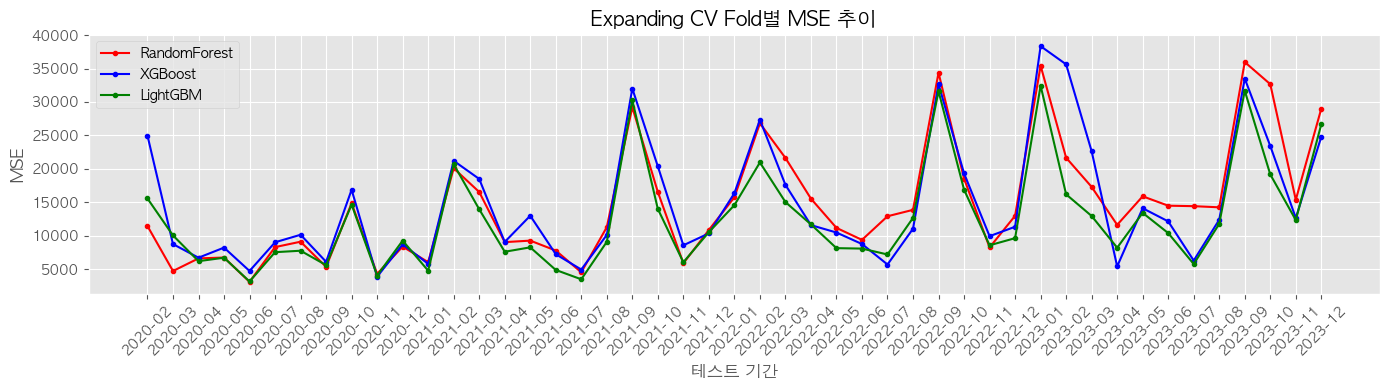

In [88]:
# 4-3. CV 결과 요약
print(f'Mean MSE (RandomForest): {df_cv["mse_rf"].mean():.2f}')
print(f'Mean MSE (XGBoost):      {df_cv["mse_xgb"].mean():.2f}')
print(f'Mean MSE (LightGBM):     {df_cv["mse_lgbm"].mean():.2f}')

# Fold별 MSE 추이 시각화
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_cv["test_period"], df_cv["mse_rf"],   label="RandomForest", color="red",   marker="o", markersize=3)
ax.plot(df_cv["test_period"], df_cv["mse_xgb"],  label="XGBoost",      color="blue",  marker="o", markersize=3)
ax.plot(df_cv["test_period"], df_cv["mse_lgbm"], label="LightGBM",     color="green", marker="o", markersize=3)
ax.set_xlabel("테스트 기간")
ax.set_ylabel("MSE")
ax.set_title("Expanding CV Fold별 MSE 추이")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_model = model_rf


## 5. 결과

### 5.1. 타겟 기간 예측 (2024년 1월)

2024년 1월 매출 데이터를 타겟으로 설정하고, 2020~2023 데이터를 학습에 사용하여 **RandomForest**, **XGBoost**, **LightGBM** 모델로 예측을 진행하였다. 각 모델의 성능은 **MSE (Mean Squared Error)** 기준으로 평가하였다.

- **RandomForest**는 CV와 최종 테스트 모두에서 일관되게 가장 낮은 MSE를 기록하며 가장 우수한 성능을 보였다.
- **LightGBM**은 중간 수준의 성능을 보였다.
- **XGBoost**는 세 모델 중 가장 높은 MSE를 기록했다.

CV에서도, 실제 테스트에서도 **RandomForest**가 일관되게 좋은 성능을 보인다는 점에서 신뢰할 수 있는 모델로 평가된다. 아래 코드에서 MSE 결과를 확인한다.


In [89]:
# %% 5-1. Model Evaluation
test_period = df_test['date'].between('2024/01/01', '2024/01/31')

x_range = np.arange(1,len(df_test[test_period])+1)
X_test = df_test[test_period][ind_vars]
y_test = df_test[test_period][dep_var]

y_pred_rf = model_rf.predict(X_test)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_lgbm = model_lgbm.predict(X_test)

mse_rf = mean_squared_error(y_pred_rf, y_test)
mse_xgb = mean_squared_error(y_pred_xgb, y_test)
mse_lgbm = mean_squared_error(y_pred_lgbm, y_test)

print(f'MSE (RandomForest): {mse_rf:.2f}')
print(f'MSE (XGBoost): {mse_xgb:.2f}')
print(f'MSE (LightGBM): {mse_lgbm:.2f}')


MSE (RandomForest): 12656.42
MSE (XGBoost): 11519.61
MSE (LightGBM): 20669.48


### 비즈니스 관점에서의 선택

비즈니스 관점에서는 이해할 수 있는 지표가 중요할 때가 있다. 따라서 MSE, MAPE, MAE 대신 누적 예측오차를 구해 각 모형을 비교하였다. 누적 예측오차는 모형이 몇 억원을 과대/과소 추정했는지 한 번에 설명할 수 있는 지표다.

$ 오차율 = \cfrac{(예측값 - 실제값)}{실제값} \times 100\% $

**RandomForest**는 CV와 최종 테스트(2024년 1월) 모두에서 일관되게 낮은 오차를 기록했다. CV에서도 안정적인 성능을 보였고 실제 예측에서도 가장 신뢰할 수 있는 결과를 제공하여, 비즈니스 현장에서 설명과 신뢰성 모두를 갖춘 모델로 선택할 수 있다.

> "2023년 이전 데이터 기반으로 2024년 1월 매출을 RandomForest 모델로 예측"


In [90]:
print(f'''
RandomForest 예측 오차   : {y_pred_rf.sum() - y_test.sum():.2f} 억원
XGBoost 예측 오차        : {y_pred_xgb.sum() - y_test.sum():.2f} 억원
LightGBM 예측 오차       : {y_pred_lgbm.sum() - y_test.sum():.2f} 억원 
''')

print(f'''
실제 매출액              : {y_test.sum():.2f} 억원
RandomForest 예측 매출액 : {y_pred_rf.sum():.2f} 억원
XGBoost 예측 매출액      : {y_pred_xgb.sum():.2f} 억원
LightGBM 예측 매출액     : {y_pred_lgbm.sum():.2f} 억원
''')

print(f'''
RandomForest 예측 오차율 : {100*(y_pred_rf.sum() - y_test.sum())/y_test.sum():.2f} %
XGBoost 예측 오차율      : {100*(y_pred_xgb.sum() - y_test.sum())/y_test.sum():.2f} %
LightGBM 예측 오차율     : {100*(y_pred_lgbm.sum() - y_test.sum())/y_test.sum():.2f} %
''')


RandomForest 예측 오차   : -445.06 억원
XGBoost 예측 오차        : -1203.23 억원
LightGBM 예측 오차       : -3520.77 억원 


실제 매출액              : 25577.36 억원
RandomForest 예측 매출액 : 25132.30 억원
XGBoost 예측 매출액      : 24374.13 억원
LightGBM 예측 매출액     : 22056.59 억원


RandomForest 예측 오차율 : -1.74 %
XGBoost 예측 오차율      : -4.70 %
LightGBM 예측 오차율     : -13.77 %



### 5.2. 예측 시각화

2024년 1월 매출 데이터를 기준으로 **RandomForest**, **XGBoost**, **LightGBM** 모델의 예측 결과와 실제 매출 데이터를 시각화한 것이다.

- **검정색 실선**은 실제 매출 데이터를 나타낸다.
- **RandomForest**(빨간색 점선), **XGBoost**(파란색 점선), **LightGBM**(녹색 점선) 모두 매출을 비교적 정확하게 예측한다.

**RandomForest**가 CV와 최종 테스트 모두에서 일관되게 가장 정확한 결과를 제공한다.


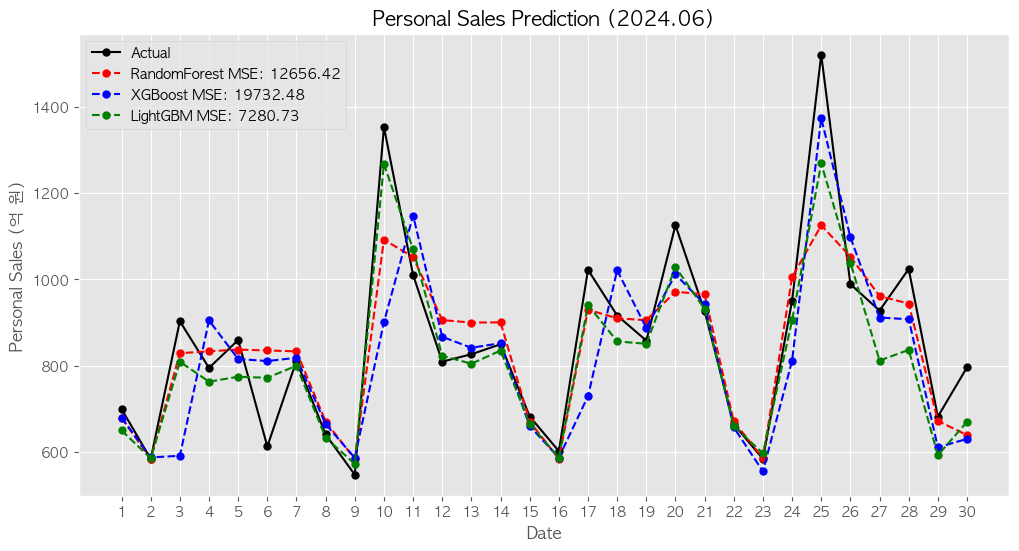

In [80]:
# %% 5-2. Model Visualization
plt.rc('figure', figsize=(12,6))

plt.plot(x_range, y_test, 
         marker='o', markersize=5, label='Actual', color='black')
plt.plot(x_range, y_pred_rf, 
         marker='o', markersize=5, label=f'RandomForest MSE: {mean_squared_error(y_pred_rf, y_test):.2f}', 
         linestyle='--', color='red')
plt.plot(x_range, y_pred_xgb,
            marker='o', markersize=5, label=f'XGBoost MSE: {mean_squared_error(y_pred_xgb, y_test):.2f}', 
            linestyle='--', color='blue')
plt.plot(x_range, y_pred_lgbm,
            marker='o', markersize=5, label=f'LightGBM MSE: {mean_squared_error(y_pred_lgbm, y_test):.2f}', 
            linestyle='--', color='green')

plt.title('Personal Sales Prediction (2024.01)')
plt.xlabel('Date')
plt.ylabel('Personal Sales (억 원)')
plt.xticks(x_range, df_test[test_period]['date'].dt.day)
plt.legend()
plt.show()

### 5.3. 특성 중요도 분석

**LightGBM 모델**을 사용하여 매출 예측에 기여한 변수들의 중요도를 시각화하였다. 각 변수의 중요도를 기반으로 매출 예측에 가장 영향을 미치는 요소를 확인할 수 있다.

- **요일(dayofweek)**: 가장 높은 중요도를 기록하며 매출 예측에 가장 중요한 변수로 나타났다. 요일별 소비 패턴의 차이가 매출 변화에 큰 영향을 미친다는 것을 의미한다.
- **승인일자**, **일(day)**: 중간 수준의 중요도를 보이며, 절대적 날짜 정보와 월 내 일자가 매출에 영향을 미친다.
- **연도(year)**, **월(month)**: 상대적으로 낮은 중요도를 보였다.

특성 중요도 분석 결과, **요일** 변수의 높은 중요도는 마케팅 전략 수립 시 요일별 소비 트렌드를 적극 반영해야 함을 시사한다.


/var/folders/pn/jn2nxhvd3lz4kb127_r8r3340000gn/T/ipykernel_14054/391873175.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fi, x='importance', y='feature', palette='crest')
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/Users/akaired/miniconda3/envs/ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/akaired/miniconda3/envs/ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/akaired/miniconda3/envs/ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 

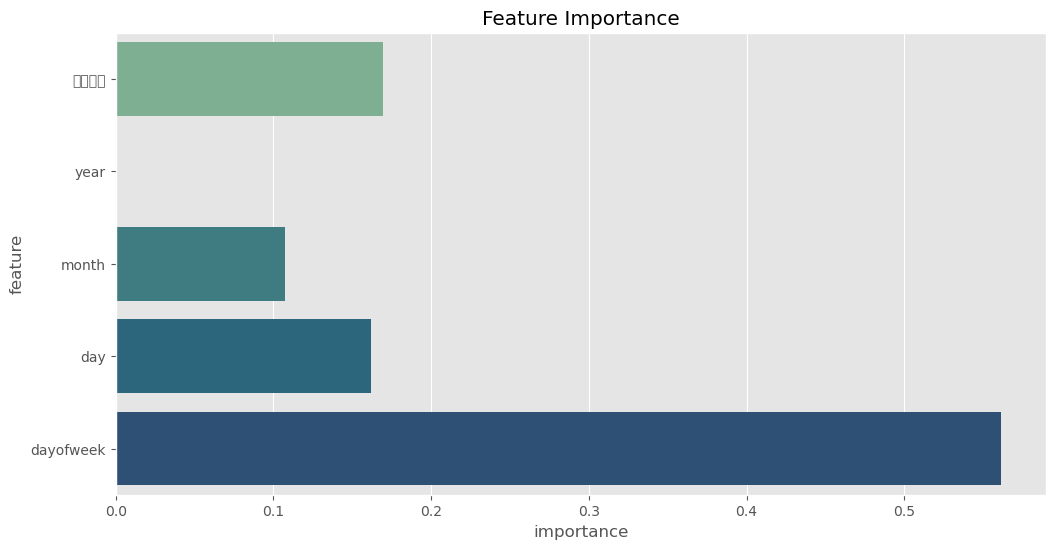

In [40]:
# %% 5-3. Model Interpretation
best_model = model_lgbm

feature_name_ko = {
    '승인일자': '승인일자',
    'year':     '연도',
    'month':    '월',
    'day':      '일',
    'dayofweek':'요일',
}

df_fi = pd.DataFrame({
    'feature':    [feature_name_ko[f] for f in X_train.columns],
    'importance':  best_model.feature_importances_,
})

plt.figure(figsize=(12,6))
sns.barplot(data=df_fi, x='importance', y='feature', hue='feature', palette='crest', legend=False)
plt.title('피처 중요도 (LightGBM)')
plt.xlabel('중요도')
plt.ylabel('피처')
plt.show()
# %%

# 6. 결론

본 프로젝트에서는 RandomForest, XGBoost, LightGBM 세 가지 모델을 활용하여 2024년 1월의 신용카드 매출을 예측하였다. Time Window Expanding Cross Validation으로 모델 성능을 평가하고, 전체 훈련 데이터(2020~2023)로 최종 모델을 학습하였다.

- **RandomForest**: CV와 최종 테스트(2024년 1월) 모두에서 일관되게 가장 낮은 MSE를 기록하며 가장 우수한 예측 성능을 보였다.
- **LightGBM**: CV와 테스트 모두에서 중간 수준의 성능을 보였다.
- **XGBoost**: 세 모델 중 가장 높은 오차를 기록했다.

CV와 실제 테스트 모두에서 **RandomForest**가 일관된 성능을 보인다는 점은 모델의 신뢰성 측면에서 중요하다. 이를 기반으로 안정적인 매출 목표 설정과 예산 계획 수립이 가능하며, 요일별 소비 패턴을 활용한 맞춤형 마케팅 전략을 통해 추가적인 매출 증대를 도모할 수 있다.

변동성이 크지 않은 신용카드 매출 데이터의 특성상 비교적 단순한 모형으로도 높은 정확도를 달성할 수 있었다. 향후 공휴일, 이벤트 등 외부 요인을 피처로 추가하면 예측 정확도를 더욱 높일 수 있을 것으로 기대된다.


# 7. References

In [41]:
import sklearn as sk
import xgboost as xgb
import lightgbm as lgb

print(f'numpy version: {np.__version__}')
print(f'pandas version: {pd.__version__}')
print(f'seaborn version: {sns.__version__}')
print(f'matplotlib version: {mpl.__version__}')
print(f'scikit-learn version: {sk.__version__}')
print(f'xgboost version: {xgb.__version__}')
print(f'lightgbm version: {lgb.__version__}')

numpy version: 1.26.4
pandas version: 2.3.1
seaborn version: 0.13.2
matplotlib version: 3.10.0
scikit-learn version: 1.7.1
xgboost version: 3.0.1
lightgbm version: 4.6.0
